In [1]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.io.wavfile as wavfile

In [4]:
# Step 0: convert to wav if not in the format
from moviepy import AudioFileClip
clip = AudioFileClip(pp)
clip.write_audiofile("out_audio.wav")


MoviePy - Writing audio in out_audio.wav


MoviePy - Done.


In [5]:
# Step 1: load wav
import librosa
import librosa.display
import matplotlib.pyplot as plt
y, sr = librosa.load('out_audio.wav') # sr = sample rate
y = y[:int(sr*30)]


c:\Users\Priyam Patel\PRML-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Step 2: do fft over the audio file and convert output to mel scale
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=1024)
# # COnvert amplitude to deibels so that difference in loudness is distinguishable
mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
# getting all values between 0 and 1
mel_spect = (mel_spect - mel_spect.min()) / (mel_spect.max() - mel_spect.min())

In [7]:
mel_spect.shape

(128, 646)

In [8]:
# code for spectogram testing(take file input->check whether it is wav or not(webm)->if webm->convert to wav using moviepy->else generate spectrogram and return mel array)
import numpy as np
import matplotlib.pyplot as plt
from moviepy import VideoFileClip
import librosa
N_FFT = 1024
HOP_LEN = 512
def generate_spectrogram(file_path):
    file_path =  "../data/genres_original/" + file_path[:file_path.find(".")] + "/" + file_path
    # some file in data set are corrupted -_-
    try:
        
        if(".wav" not in file_path):
            # Step 1: convert to wav if not in the format
            clip = VideoFileClip(file_path)
            clip.audio.write_audiofile("out_audio.wav")
            file_path="out_audio.wav"
        y, sr = librosa.load(file_path) #sr sample rate
        # some sample smaller than 30s
        print(len(y))
        if len(y) < sr*30:
            y = np.pad(y, (0, int(sr*30) - len(y)))
        y = y[:int(sr*30)]
        # Step 2: do fft over the audio file and convert output to mel scale
        mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN)
        # # Convert amplitude to decibels so that difference in loudness is distinguishable
        mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
        # getting all values between 0 and 1
        mel_spect = (mel_spect - mel_spect.min()) / (mel_spect.max() - mel_spect.min())
        return mel_spect
    except Exception:
        print(file_path)
        print("Audio corrupt.. skip")
        return None

In [9]:
import os
from sklearn.preprocessing import LabelEncoder
import numpy as np

def preprocess():
    data = "../data/genres_original"
    x = []
    y = []

    # loop over folder and sub-folder
    for genre_folder in os.scandir(data):
        for files in os.scandir(genre_folder):
            # get sample
            sample = files.name
            spectogram = generate_spectrogram(sample)
            # if corrupt then dont add
            if spectogram is not None:
                x.append(spectogram)
                y.append(sample[:sample.find(".")])
    
    # get string to num maping
    mapping = LabelEncoder()
    y = mapping.fit_transform(y)
    mapping = dict(zip(range(len(mapping.classes_)), mapping.classes_))
    x = np.array(x)
    
    
    return x,y,mapping

x,y,mapping = preprocess()

661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
669680

C:\Users\Priyam Patel\AppData\Local\Temp\ipykernel_24344\2370926190.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path) #sr sample rate
c:\Users\Priyam Patel\PRML-Project\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


661794
666820
661794
669240
661980
661794
667480
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661794
661794
661794
661794
661794
661504
661504
661504

In [10]:
# convert to torch format which expects [batchsize, channels, height, width]
x_tensor = x[:, np.newaxis,:,:]
x_tensor = torch.tensor(x_tensor, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
x_tensor.shape

torch.Size([999, 1, 128, 1292])

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_, y_train, y_ = train_test_split(
    x_tensor, y_tensor,
    test_size=0.15,
    random_state=90,
    stratify=y_tensor,
)
x_val,x_test,y_val,y_test = train_test_split(
    x_, y_,
    test_size=0.33,
    random_state=90,
    stratify=y_,
)
traindataset = TensorDataset(x_train, y_train)
trainloader = DataLoader(traindataset, batch_size=4, shuffle=True)

valdataset = TensorDataset(x_val, y_val)
valloader = DataLoader(valdataset, batch_size=4, shuffle=False)

testdataset = TensorDataset(x_test, y_test)
testloader = DataLoader(testdataset, batch_size=4, shuffle=False)

In [12]:
max_val_acc = -1

In [15]:
from torch.optim import lr_scheduler

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        # FEATURE EXTRACTOR: Learns spatial patterns (edges, textures, shapes)
        self.features = nn.Sequential(
            # Layer 1: Conv -> ReLU -> Pool
            # Input: 3 channels (RGB), 32x32 matrix. Output: 16 channels, 32x32
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=4, padding=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16),
            # MaxPool reduces dimensions by half. Output: 16 channels, 16x16 matrix
            nn.MaxPool2d(kernel_size=5, stride=5),

            # Layer 2: Conv -> ReLU -> Pool
            # Input: 16 channels, 16x16. Output: 32 channels, 16x16
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, padding=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            # Output: 32 channels, 8x8 matrix
            nn.MaxPool2d(kernel_size=5, stride=5)
        )

        # CLASSIFIER: Takes the extracted features and makes a decision
        self.classifier = nn.Sequential(
            
            nn.Linear(8160, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.67), # Drops 67% of neurons randomly to prevent memorization (overfitting)
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)         # 1. Pass through convolutional layers
        x = torch.flatten(x, 1)      # 2. Flatten from 2D grids into a 1D vector
        x = self.classifier(x)       # 3. Pass through dense/linear layers
        return x

In [ ]:
model = CNN()
model = model.to("cuda")
validation_accuracies = []
training_loss = []
criterion = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), 0.0001)
device = "cuda"
print("Starting Training...")
epo = 20
for epoch in range(epo):
    model.train()
    running_loss = 0.0

    for x, y in trainloader:
        x, y = x.to("cuda"), y.to("cuda")

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    training_loss.append(avg_train_loss)
    
    print(f"Epoch [{epoch+1}/{epo}], Loss: {avg_train_loss:.4f}")

    # Evaluate model on test data
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in valloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_accuracy = 100 * correct / total
    max_val_acc = max(val_accuracy,max_val_acc)
    if(val_accuracy == max_val_acc):
        print("Saving at accuracy", val_accuracy)
        torch.save(model.state_dict(), "model.pth")
    print(f"Val Accuracy: {val_accuracy:.2f}%\n")
    validation_accuracies.append(val_accuracy)
    
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in testloader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

test_accuracy = 100 * correct / total
print("Test Acc", test_accuracy)

Starting Training...
Epoch [1/20], Loss: 2.3873
Saving at accuracy 33.0
Val Accuracy: 33.00%

Epoch [2/20], Loss: 2.0158
Saving at accuracy 40.0
Val Accuracy: 40.00%

Epoch [3/20], Loss: 1.9302
Saving at accuracy 45.0
Val Accuracy: 45.00%

Epoch [4/20], Loss: 1.7517
Saving at accuracy 45.0
Val Accuracy: 45.00%

Epoch [5/20], Loss: 1.5838
Saving at accuracy 57.0
Val Accuracy: 57.00%

Epoch [6/20], Loss: 1.4649
Saving at accuracy 57.0
Val Accuracy: 57.00%

Epoch [7/20], Loss: 1.3439
Val Accuracy: 55.00%

Epoch [8/20], Loss: 1.2709
Val Accuracy: 53.00%

Epoch [9/20], Loss: 1.1736
Saving at accuracy 62.0
Val Accuracy: 62.00%

Epoch [10/20], Loss: 1.0627
Val Accuracy: 59.00%

Epoch [11/20], Loss: 0.8739
Saving at accuracy 62.0
Val Accuracy: 62.00%

Epoch [12/20], Loss: 0.9381
Saving at accuracy 66.0
Val Accuracy: 66.00%

Epoch [13/20], Loss: 0.7635
Val Accuracy: 64.00%

Epoch [14/20], Loss: 0.7081
Saving at accuracy 66.0
Val Accuracy: 66.00%

Epoch [15/20], Loss: 0.6373
Saving at accuracy 6

In [17]:
torch.save(model.state_dict(), "model.pth")

Text(0, 0.5, 'Accuracy (%age)')

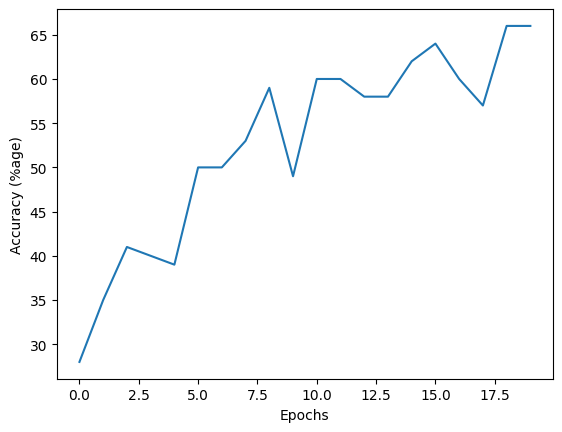

In [100]:
plt.plot(validation_accuracies)
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%age)")

Text(0, 0.5, 'Cross-Entropy Loss')

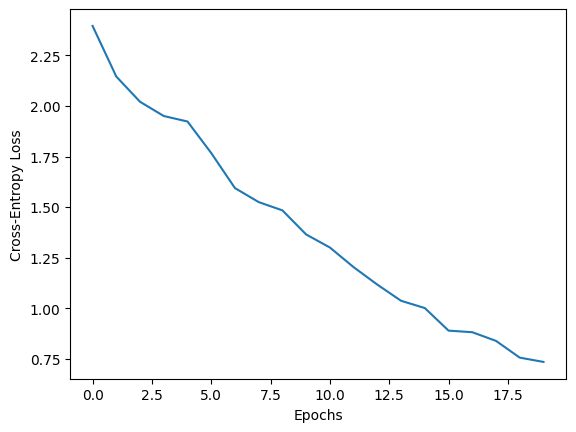

In [101]:
plt.plot(training_loss)
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")

In [98]:
loaded_model = CNN()
loaded_model.load_state_dict(torch.load("../model.pth"))

C:\Users\Priyam Patel\AppData\Local\Temp\ipykernel_24344\3652627878.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("../model.pth

<All keys matched successfully>

In [99]:
loaded_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in testloader:
        # x, y = x.to(device), y.to(device)
        outputs = loaded_model(x)
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

test_accuracy = 100 * correct / total
print("Test Acc", test_accuracy)

Test Acc 82.0
